In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")


In [ ]:
bins = [0, 6, 12, 24, 36, 48, np.inf]
labels = ['0-6 M', '7-12 M', '13-24 M',
          '25-36 M', '37-48 M', '48+ M']

df['Tenure_Cohort'] = pd.cut(
    df['Tenure'],
    bins=bins,
    labels=labels
)


In [ ]:
cohort = df.groupby('Tenure_Cohort').agg(
    Customers=('CustomerID', 'count'),
    Avg_Spend=('Total Spend', 'mean'),
    Avg_Usage=('Usage Frequency', 'mean'),
    Avg_Support_Calls=('Support Calls', 'mean'),
    Churn_Rate=('Churn', 'mean')
).reset_index()

cohort['Churn_Rate'] *= 100

print(cohort)



  Tenure_Cohort  Customers   Avg_Spend  Avg_Usage  Avg_Support_Calls  \
0         0-6 M      40378  621.151043  15.481970           3.783496   
1        7-12 M      44751  633.143997  15.769055           3.584881   
2       13-24 M      79967  619.847030  17.030212           3.812910   
3       25-36 M      91473  637.326444  15.521957           3.508751   
4       37-48 M      91932  636.739867  15.488796           3.522179   
5         48+ M      92331  634.886877  15.509699           3.531750   

   Churn_Rate  
0   62.353262  
1   55.469152  
2   63.272350  
3   54.124168  
4   54.126963  
5   54.297040  


/tmp/ipykernel_5594/3269391916.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby('Tenure_Cohort').agg(


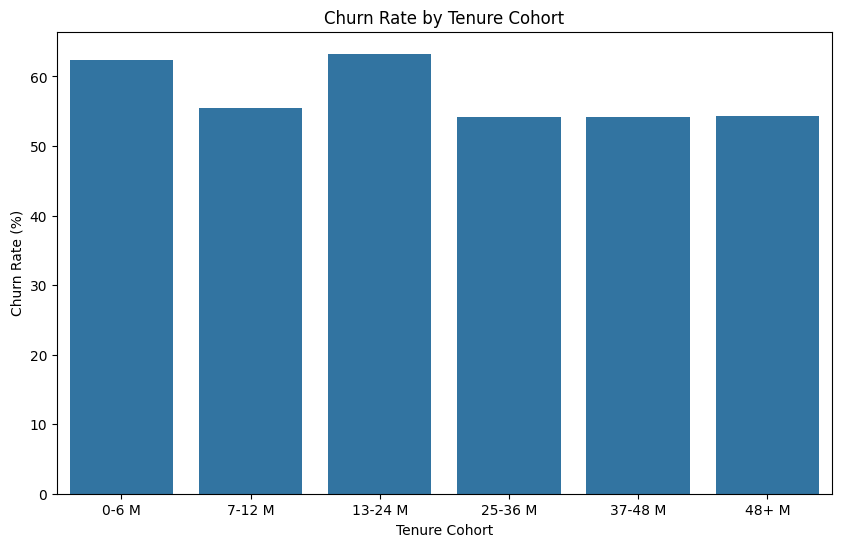

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=cohort,
    x='Tenure_Cohort',
    y='Churn_Rate'
)
plt.title('Churn Rate by Tenure Cohort')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Cohort')
plt.show()


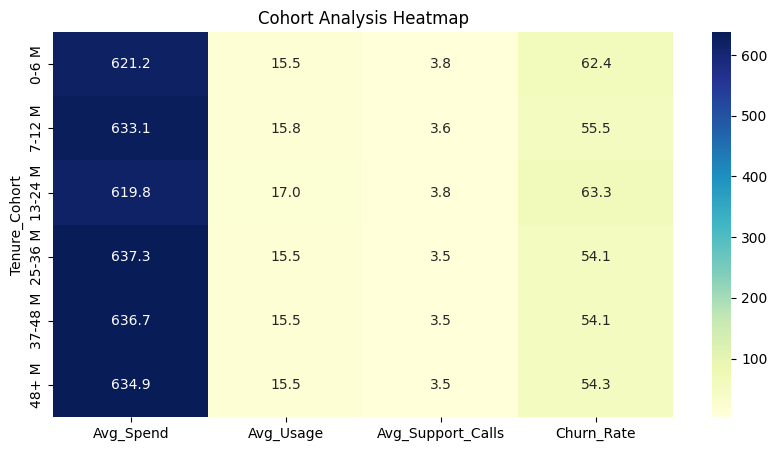

In [ ]:
heatmap_data = cohort.set_index('Tenure_Cohort')[[
    'Avg_Spend',
    'Avg_Usage',
    'Avg_Support_Calls',
    'Churn_Rate'
]]

plt.figure(figsize=(10,5))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)
plt.title('Cohort Analysis Heatmap')
plt.show()